## `desi_sampling.ipynb`

This notebook serves to sample DESI to a smaller catalog covering HSC's footprint and display both footprints.

In [1]:
## Imports
import numpy as np
import glob
import matplotlib.pyplot as plt
import os
import fitsio as fio

from pathlib import Path
from astropy import units as u
from astropy.coordinates import SkyCoord
from astropy.table import Table

In [ ]:
desi_file = Path('/global/cfs/cdirs/desi/spectro/redux/loa', 'zcatalog', 'v1', 'zall-pix-loa.fits')
print(f'DESI catalog : {desi_file}')

desi_sample_file = Path('/global/cfs/cdirs/desicollab/users/jchdj/desi-y3-hsc/data/desi/cat/desiy3_cut_cat.fits')
print(f'DESI sampled catalog : {desi_sample_file}')

hsc_root = os.environ['HSC']
hsc_file = Path('/global/cfs/cdirs/desicollab/users/jchdj/desi-y3-hsc/data/hsc/cat/', 'hscy3_cat.fits')
print(f'HSC catalog : {hsc_file}')

DESI catalog : /global/cfs/cdirs/desi/spectro/redux/loa/zcatalog/v1/zall-pix-loa.fits
DESI sampled catalog : /global/cfs/cdirs/desicollab/users/jchdj/desi-y3-hsc/data/desi/cat/desiy3_cut_cat.fits
HSC catalog :  /global/cfs/cdirs/desicollab/users/jchdj/desi-y3-hsc/data/hsc/cat/hscy3_cat.fits


### Loading Datasets

In [8]:
# Show DESI columns
desi_hdu = fio.FITS(desi_file)
print(f'Available columns :\n{desi_hdu[1].get_colnames()}')

Available columns :
['TARGETID', 'SURVEY', 'PROGRAM', 'HEALPIX', 'SPGRPVAL', 'Z', 'ZERR', 'ZWARN', 'CHI2', 'COEFF', 'FITMETHOD', 'NPIXELS', 'SPECTYPE', 'SUBTYPE', 'NCOEFF', 'DELTACHI2', 'COADD_FIBERSTATUS', 'TARGET_RA', 'TARGET_DEC', 'DESINAME', 'PMRA', 'PMDEC', 'REF_EPOCH', 'FA_TARGET', 'FA_TYPE', 'OBJTYPE', 'SUBPRIORITY', 'OBSCONDITIONS', 'RELEASE', 'BRICKNAME', 'BRICKID', 'BRICK_OBJID', 'MORPHTYPE', 'EBV', 'FLUX_G', 'FLUX_R', 'FLUX_Z', 'FLUX_W1', 'FLUX_W2', 'FLUX_IVAR_G', 'FLUX_IVAR_R', 'FLUX_IVAR_Z', 'FLUX_IVAR_W1', 'FLUX_IVAR_W2', 'FIBERFLUX_G', 'FIBERFLUX_R', 'FIBERFLUX_Z', 'FIBERTOTFLUX_G', 'FIBERTOTFLUX_R', 'FIBERTOTFLUX_Z', 'MASKBITS', 'SERSIC', 'SHAPE_R', 'SHAPE_E1', 'SHAPE_E2', 'REF_ID', 'REF_CAT', 'GAIA_PHOT_G_MEAN_MAG', 'GAIA_PHOT_BP_MEAN_MAG', 'GAIA_PHOT_RP_MEAN_MAG', 'PARALLAX', 'PHOTSYS', 'PRIORITY_INIT', 'NUMOBS_INIT', 'CMX_TARGET', 'DESI_TARGET', 'BGS_TARGET', 'MWS_TARGET', 'SCND_TARGET', 'SV1_DESI_TARGET', 'SV1_BGS_TARGET', 'SV1_MWS_TARGET', 'SV1_SCND_TARGET', 'SV2_D

In [ ]:
# We select a subset of the DESI catalog to have an easier time memory wise later on.
def spatial_crit(ra, dec):
    '''
    Defines a criteria based on the HSC footprint to reduce the desi zall catalog.
    '''
    ra, dec = np.asarray(ra), np.asarray(dec)
    return (
        ((dec > -8) & (dec < 8)) | ((dec > 40) & (dec < 47) & (ra > 180)) 
    )

desi_coords = Table(desi_hdu[1].read(['TARGETID', 'TARGET_RA', 'TARGET_DEC']))
mask = spatial_crit(desi_coords['TARGET_RA'], desi_coords['TARGET_DEC'])

print(f'Number of objects in file : {desi_hdu[1].get_nrows()}')
print(f'Example sources masked out : {mask[0::20000][0:10]}')
print(f'Number of objects after cut : {np.sum(mask)}')
print(f'Percentage of objects kept : {np.sum(mask)/len(mask)*100:.2f}%')

# Let's get the row indices of the objects we want to keep
indices = np.flatnonzero(mask)
print(f'Indices of objects kept : {indices[0:5]} ... {indices[-5:]}')

Number of objects in file : 64100684
Example sources masked out : [False False False False False False False False False False]
Number of objects after cut : 22971426
Percentage of objects kept : 35.84%
Indices of objects kept : [5000 5001 5002 5003 5004] ... [64053838 64053839 64053840 64053841 64053842]


We select only a few columns in order to reduce memory overhead. Could select more if so desired.

['TARGETID', 'SURVEY', 'PROGRAM', 'HEALPIX', 'Z', 'ZERR', 'ZWARN', 'CHI2', 'SPECTYPE', 'SUBTYPE', 'DELTACHI2', 'TARGET_RA', 'TARGET_DEC', 'DESINAME', 'RELEASE', 'MASKBITS', 'SERSIC', 'SHAPE_R', 'SHAPE_E1', 'SHAPE_E2', 'DESI_TARGET', 'BGS_TARGET', 'MWS_TARGET', 'SCND_TARGET', 'MAIN_NSPEC', 'MAIN_PRIMARY', 'SV_NSPEC', 'SV_PRIMARY', 'ZCAT_NSPEC', 'ZCAT_PRIMARY']

In [9]:
cols = ['TARGETID', 'SURVEY', 'PROGRAM', 'HEALPIX', 'Z', 'ZERR', 'ZWARN', 'CHI2', 'SPECTYPE', 'SUBTYPE', 'DELTACHI2', 'TARGET_RA', 'TARGET_DEC', 'DESINAME', 'RELEASE', 'MASKBITS', 'SERSIC', 'SHAPE_R', 'SHAPE_E1', 'SHAPE_E2', 'DESI_TARGET', 'BGS_TARGET', 'MWS_TARGET', 'SCND_TARGET', 'MAIN_NSPEC', 'MAIN_PRIMARY', 'SV_NSPEC', 'SV_PRIMARY', 'ZCAT_NSPEC', 'ZCAT_PRIMARY']

In [10]:
print(f'Attempting to write {len(indices)} objects to {desi_sample_file}')
desi_sample_data = desi_hdu[1].read(rows=indices, columns=cols)
print(f'Writing {desi_sample_data.shape[0]} rows to {desi_sample_file}')
fio.write(desi_sample_file, desi_sample_data, clobber=True)

Attempting to write 22971426 objects to /global/cfs/cdirs/desicollab/users/jchdj/desi-y3-hsc/data/desi/cat/desiy3_cut_cat.fits
Writing 22971426 rows to /global/cfs/cdirs/desicollab/users/jchdj/desi-y3-hsc/data/desi/cat/desiy3_cut_cat.fits


In [11]:
desi_sample_hdu = fio.FITS(desi_sample_file)
print(f'Available columns :\n{desi_sample_hdu[1].get_colnames()}')
print(f'Number of objects in file : {desi_sample_hdu[1].get_nrows()}')

Available columns :
['TARGETID', 'SURVEY', 'PROGRAM', 'HEALPIX', 'Z', 'ZERR', 'ZWARN', 'CHI2', 'SPECTYPE', 'SUBTYPE', 'DELTACHI2', 'TARGET_RA', 'TARGET_DEC', 'DESINAME', 'RELEASE', 'MASKBITS', 'SERSIC', 'SHAPE_R', 'SHAPE_E1', 'SHAPE_E2', 'DESI_TARGET', 'BGS_TARGET', 'MWS_TARGET', 'SCND_TARGET', 'MAIN_NSPEC', 'MAIN_PRIMARY', 'SV_NSPEC', 'SV_PRIMARY', 'ZCAT_NSPEC', 'ZCAT_PRIMARY']
Number of objects in file : 22971426


In [12]:
# Reading DESI sampled coordinates
desi_sample_hdu = fio.FITS(desi_sample_file)
desi_sample_coords = Table(desi_sample_hdu[1].read(['TARGETID', 'TARGET_RA', 'TARGET_DEC']))

In [13]:
# Show HSC information
hsc_data = fio.FITS(hsc_file)
print(f'Available columns :\n{hsc_data[1].get_colnames()}')
print(f'Number of objects in file : {hsc_data[1].get_nrows()}')
hsc_coords = Table(hsc_data[1].read(['object_id', 'RA', 'Dec']))

Available columns :
['RA', 'Dec', 'object_id', 'e_1', 'e_2', 'e_rms', 'weight', 'm_corr', 'c_1', 'c_2', 'resolution', 'aperture_mag', 'z_bin', 'dnnz_photoz_best', 'dnnz_photoz_risk_best', 'dnnz_photoz_std_best', 'dnnz_photoz_err68_min', 'dnnz_photoz_err68_max', 'dnnz_photoz_err95_min', 'dnnz_photoz_err95_max', 'e1_psf', 'e2_psf']
Number of objects in file : 25260877


### Showcasing footprints

In [14]:
print('Loading HSC coordinates')
coords_hsc = SkyCoord(
    ra=hsc_coords['RA'], dec=hsc_coords['Dec'], unit=(u.deg, u.deg), frame='icrs'
    )
print('Loading DESI coordinates')
coords_desi_all = SkyCoord(
    ra=desi_coords['TARGET_RA'], dec=desi_coords['TARGET_DEC'], unit=(u.deg, u.deg), frame='icrs'
    )
print('Loading DESI sampled coordinates')
coords_desi_sample = SkyCoord(
    ra=desi_sample_coords['TARGET_RA'], dec=desi_sample_coords['TARGET_DEC'], unit=(u.deg, u.deg), frame='icrs'
    )

Loading HSC coordinates
Loading DESI coordinates
Loading DESI sampled coordinates


Finished loading DESI coordinates
Finished loading DESI sample coordinates
Finished loading HSC coordinates
Finished plotting DESI coordinates
Finished plotting DESI sampled coordinates
Finished plotting HSC coordinates


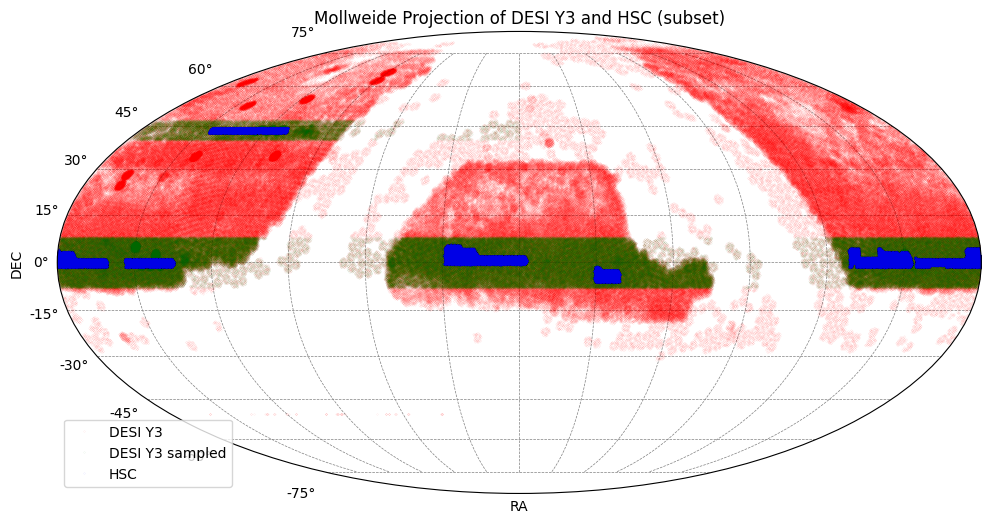

In [15]:
# First, convert to rad for mollweide projection
ra_desi = np.deg2rad(desi_coords['TARGET_RA'][0::100])
dec_desi = np.deg2rad(desi_coords['TARGET_DEC'][0::100])
print(f'Finished loading DESI coordinates')
ra_sample_desi = np.deg2rad(desi_sample_coords['TARGET_RA'][0::100])
dec_sample_desi = np.deg2rad(desi_sample_coords['TARGET_DEC'][0::100])
print(f'Finished loading DESI sample coordinates')
ra_hsc = np.deg2rad(hsc_coords['RA'][0::100])
dec_hsc = np.deg2rad(hsc_coords['Dec'][0::100])
print(f'Finished loading HSC coordinates')

# Wrap RA coordinates to [-pi, pi]
ra_desi_wrapped = np.remainder(ra_desi + np.pi, 2*np.pi) - np.pi
ra_sample_desi_wrapped = np.remainder(ra_sample_desi + np.pi, 2*np.pi) - np.pi
ra_hsc_wrapped = np.remainder(ra_hsc + np.pi, 2*np.pi) - np.pi

plt.figure(figsize=(12, 6))
ax = plt.subplot(111, projection='mollweide')
ax.plot(ra_desi_wrapped, dec_desi, 'r.', markersize=0.1, label='DESI Y3', alpha=0.5)
print(f'Finished plotting DESI coordinates')
ax.plot(ra_sample_desi_wrapped, dec_sample_desi, 'g.', markersize=0.1, label='DESI Y3 sampled', alpha=0.5)
print(f'Finished plotting DESI sampled coordinates')
ax.plot(ra_hsc_wrapped, dec_hsc, 'b.', markersize=0.1, label='HSC', alpha=0.5)
print(f'Finished plotting HSC coordinates')

ax.grid(color='gray', linestyle='--', linewidth=0.5)
ax.set_xticklabels([])
ax.legend(loc='lower left')
ax.set_xlabel('RA')
ax.set_ylabel('DEC')
plt.title('Mollweide Projection of DESI Y3 and HSC (subset)')
plt.show()